# L0.3 — Vectors

Hands-on notebook for the lesson [`0-3-vectors.mdx`](../../llm-quest-theory/level-0/0-3-vectors.mdx).

> **Learning objectives**
> - Get fluent with vector ops in NumPy: addition, scalar multiplication, norm, dot product.
> - Visualize vector addition and the meaning of the dot product.
> - Compute cosine similarity between two sentences via one-hot bag-of-words — a miniature of "semantic search" in RAG.

## Connection to the theory
Covers **§1–§4** of the `.mdx`. When you meet attention in level 4, `Q · K^T` is just a batch of dot products — same kind of thing as in this notebook.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Basic vector ops

In [2]:
u = np.array([3, 4])
v = np.array([1, 2])

print("u + v      =", u + v)
print("2 * u      =", 2 * u)
print("||u||      =", np.linalg.norm(u))
print("u . v      =", np.dot(u, v))
print("cos(u,v)   =", np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))

u + v      = [4 6]
2 * u      = [6 8]
||u||      = 5.0
u . v      = 11
cos(u,v)   = 0.9838699100999074


## 2. Tip-to-tail visualization
Addition = place the tail of `v` at the head of `u`.

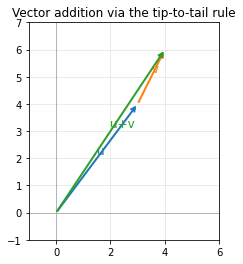

In [3]:
def draw_vec(ax, start, vec, color, label):
    ax.annotate("", xy=start+vec, xytext=start,
                arrowprops=dict(arrowstyle="->", color=color, lw=2))
    mid = start + vec / 2
    ax.text(mid[0], mid[1] + 0.15, label, color=color, fontsize=12)

fig, ax = plt.subplots()
origin = np.array([0, 0])
draw_vec(ax, origin, u, "tab:blue", "u")
draw_vec(ax, u, v, "tab:orange", "v")
draw_vec(ax, origin, u + v, "tab:green", "u+v")

ax.set_xlim(-1, 6); ax.set_ylim(-1, 7); ax.set_aspect("equal")
ax.grid(alpha=0.3); ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_title("Vector addition via the tip-to-tail rule"); plt.show()

## 3. Dot product and the angle between two vectors
Verify the formula `u . v = |u||v|cos(theta)`.

In [4]:
def angle_deg(a, b):
    cos = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    cos = np.clip(cos, -1, 1)
    return float(np.degrees(np.arccos(cos)))

pairs = [
    ([3, 0], [0, 3]),   # perpendicular
    ([2, 2], [2, 2]),   # identical
    ([1, 0], [-1, 0]),  # opposite
    ([1, 0], [1, 1]),   # 45 deg
]
for a, b in pairs:
    a, b = np.array(a), np.array(b)
    print(f"u={a}, v={b}  ->  u.v={np.dot(a, b):>4},  angle={angle_deg(a, b):.1f} deg")

u=[3 0], v=[0 3]  ->  u.v=   0,  angle=90.0 deg
u=[2 2], v=[2 2]  ->  u.v=   8,  angle=0.0 deg
u=[1 0], v=[-1  0]  ->  u.v=  -1,  angle=180.0 deg
u=[1 0], v=[1 1]  ->  u.v=   1,  angle=45.0 deg


## 4. Cosine similarity over a bag-of-words
A mini version of semantic search: represent each sentence by a word-count vector over the vocabulary, then compute cosine between the query and each document sentence.

In [5]:
docs = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "transformers use attention to process tokens",
    "attention heads read keys and queries",
]
query = "attention over tokens"

vocab = sorted({w for s in docs + [query] for w in s.split()})
index = {w: i for i, w in enumerate(vocab)}

def to_bow(sentence):
    vec = np.zeros(len(vocab))
    for w in sentence.split():
        vec[index[w]] += 1
    return vec

def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

q = to_bow(query)
for d in docs:
    print(f"  {cos_sim(q, to_bow(d)):.3f}  <-  {d!r}")

  0.000  <-  'the cat sat on the mat'
  0.000  <-  'the dog sat on the rug'
  0.471  <-  'transformers use attention to process tokens'
  0.236  <-  'attention heads read keys and queries'


Observation: the two sentences about attention/tokens score higher than the "cat/dog sat on the mat" ones, even with the crude bag-of-words. With learned embeddings (level 5), this distance will carry real semantic meaning.

## 5. Quick checks

In [6]:
# Self-check a few properties
assert np.allclose(np.dot([3, 0], [0, 3]), 0),   "perpendicular -> dot = 0"
assert np.linalg.norm([3, 4]) == 5.0,             "Pythagoras"
assert np.isclose(cos_sim(np.array([1.0, 0]), np.array([2.0, 0])), 1.0), "same direction -> cos = 1"
print("All assertions passed.")

All assertions passed.


## Reflection questions

1. Why does cosine similarity discard the "length" of a vector? When does this hurt?
2. If two sentences use entirely different words but share the same topic, how will bag-of-words + cosine score them? How do embeddings learned from a large corpus help?
3. In attention, `Q · K^T` is divided by `sqrt(d)` — why?

## References
- Source theory: [`0-3-vectors.mdx`](../../llm-quest-theory/level-0/0-3-vectors.mdx)
- Next: [`0-4-matrices`](0-4-matrices.ipynb)